In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.special import expit as sigmoid
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## Kidney Allocation Preference Study — Empirical Analysis

**Data**: `kidneypairwise2.csv`  
**Task**: For each pairwise comparison, the respondent chose between two kidney recipients described by 5 features. We fit a Bradley-Terry-Luce (BTL) model per respondent to recover their preference vector θ, then analyse distortion under the strategy-proof RLHF mechanism.

**Features** (5):
| Column | Meaning |
|---|---|
| `elderlyDep` | Number of elderly dependants (0–3) |
| `lifeYearsGained` | Life-years gained by transplant (−1 to 25) |
| `obesity` | Obesity level (0–4) |
| `weeklyWorkhours` | Work hours per week (0–50) |
| `yearsWaiting` | Years on waiting list (1–7) |

**Encoding**: `chosen=1` → left (l\_) option selected; `chosen=0` → right (r\_) option selected.

Loaded 33,024 rows, 82 unique respondents
chosen distribution: {0: 16617, 1: 16407}

Feature ranges:
  elderlyDep: [0, 1, 2, 3]
  lifeYearsGained: [-1, 5, 10, 15, 20, 25]
  obesity: [0, 1, 2, 3, 4]
  weeklyWorkhours: [0, 10, 20, 30, 40, 50]
  yearsWaiting: [1, 3, 5, 7]


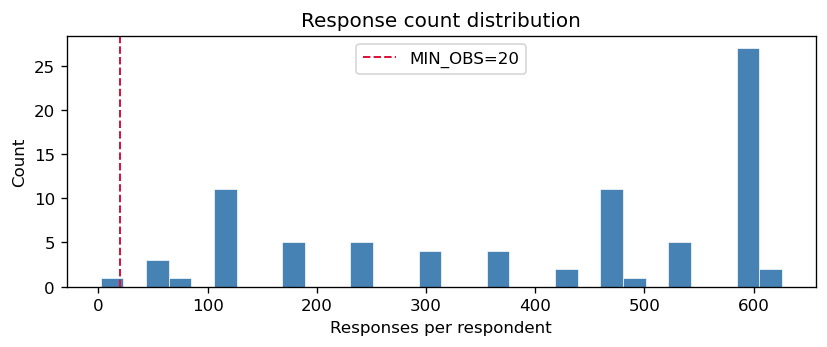


Eligible respondents (≥20 responses): 81 / 82


In [20]:
FEAT_COLS = ['elderlyDep', 'lifeYearsGained', 'obesity', 'weeklyWorkhours', 'yearsWaiting']
L_COLS    = [f'l_{f}' for f in FEAT_COLS]
R_COLS    = [f'r_{f}' for f in FEAT_COLS]
MIN_OBS   = 20   # minimum responses required to fit individual BTL

df = pd.read_csv('kidneypairwise2.csv')
print(f"Loaded {len(df):,} rows, {df['id'].nunique()} unique respondents")
print(f"chosen distribution: {df['chosen'].value_counts().to_dict()}")
print(f"\nFeature ranges:")
for f in FEAT_COLS:
    vals = sorted(pd.concat([df[f'l_{f}'], df[f'r_{f}']]).unique().tolist())
    print(f"  {f}: {vals}")

# ── Response-count histogram ──────────────────────────────────────────────
counts = df.groupby('id').size()
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(counts.values, bins=30, edgecolor='white', linewidth=0.4, color='steelblue')
ax.axvline(MIN_OBS, color='crimson', ls='--', lw=1.2, label=f'MIN_OBS={MIN_OBS}')
ax.set_xlabel('Responses per respondent'); ax.set_ylabel('Count')
ax.set_title('Response count distribution'); ax.legend()
plt.tight_layout(); plt.show()

eligible_ids = counts[counts >= MIN_OBS].index
print(f"\nEligible respondents (≥{MIN_OBS} responses): {len(eligible_ids)} / {df['id'].nunique()}")

In [21]:
def build_alpha_y(df_sub, feat_cols=FEAT_COLS):
    """alpha = l_features − r_features,  y = chosen (1=left, 0=right)."""
    l_cols = [f'l_{f}' for f in feat_cols]
    r_cols = [f'r_{f}' for f in feat_cols]
    alpha = (df_sub[l_cols].values - df_sub[r_cols].values).astype(float)
    y     = df_sub['chosen'].values.astype(float)
    return alpha, y

def fit_btl(alpha, y=None, C=1.0):
    """Logistic regression (no intercept) on alpha vectors."""
    if y is None:
        y = np.ones(len(alpha))
    lr = LogisticRegression(fit_intercept=False, C=C, solver='lbfgs',
                            max_iter=2000, tol=1e-8)
    lr.fit(alpha, y)
    return lr.coef_.ravel()

# ── Build pooled alpha matrix ─────────────────────────────────────────────
df_elig = df[df['id'].isin(eligible_ids)].copy()
alpha_all, y_all = build_alpha_y(df_elig)
print(f"Pooled dataset: {len(alpha_all):,} pairwise comparisons")

# ── Per-person BTL fits ───────────────────────────────────────────────────
theta_records = []
for pid in eligible_ids:
    df_p  = df_elig[df_elig['id'] == pid]
    a, y  = build_alpha_y(df_p)
    theta = fit_btl(a, y)
    theta_records.append({'id': pid, **dict(zip(FEAT_COLS, theta))})

theta_df = pd.DataFrame(theta_records).set_index('id')
print(f"\nFitted {len(theta_df)} individual BTL models")
print("\nPer-feature θ distribution:")
print(theta_df[FEAT_COLS].describe().round(4).to_string())

Pooled dataset: 33,022 pairwise comparisons

Fitted 81 individual BTL models

Per-feature θ distribution:
       elderlyDep  lifeYearsGained  obesity  weeklyWorkhours  yearsWaiting
count     81.0000          81.0000  81.0000          81.0000       81.0000
mean      -0.7923          -0.3212   0.3046          -0.0241       -0.5863
std        0.7386           0.2960   0.3467           0.0331        0.5716
min       -3.3546          -2.0459  -0.3586          -0.1127       -2.4890
25%       -1.0472          -0.3935   0.0600          -0.0376       -0.7384
50%       -0.6293          -0.2526   0.2636          -0.0193       -0.3819
75%       -0.2559          -0.1511   0.4870          -0.0081       -0.2203
max        0.2245          -0.0205   1.9668           0.1252        0.0268


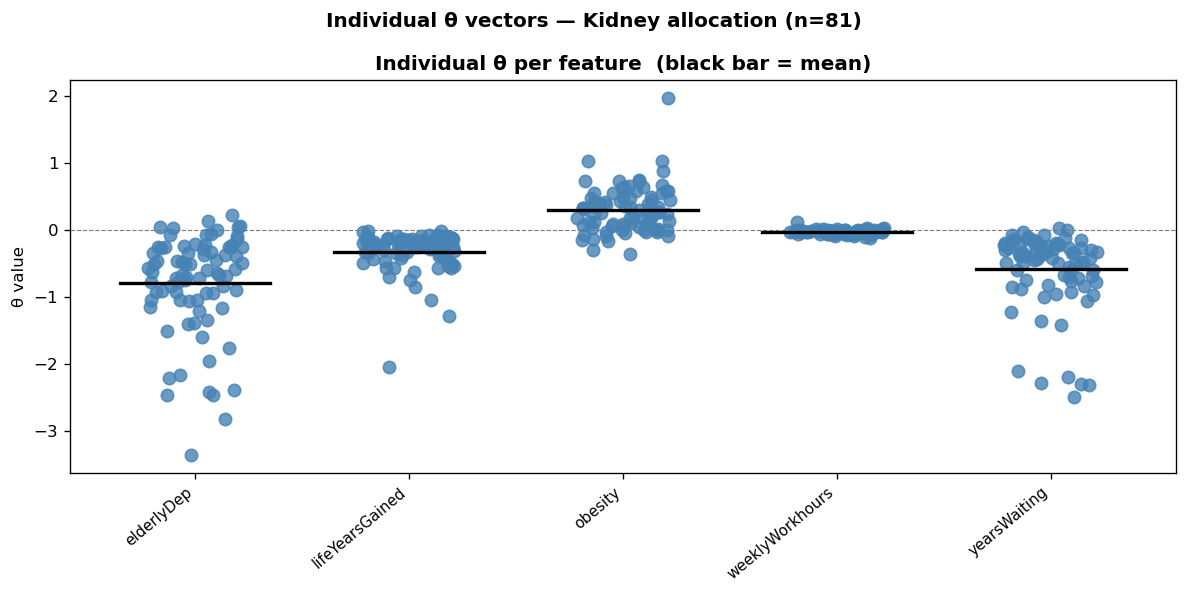

In [41]:
# ── Strip plot: individual θ per feature (black bar = mean) ──────────────
fig, ax = plt.subplots(figsize=(10, 5))
rng_j = np.random.default_rng(0)
for i, feat in enumerate(FEAT_COLS):
    vals = theta_df[feat].values
    jitter = rng_j.uniform(-0.22, 0.22, size=len(vals))
    ax.scatter(i + jitter, vals, color='steelblue', s=55, alpha=0.8, zorder=3)
    ax.plot([i - 0.35, i + 0.35], [vals.mean(), vals.mean()],
            color='black', lw=2.0, zorder=4)

ax.axhline(0, color='grey', ls='--', lw=0.7)
ax.set_xticks(range(len(FEAT_COLS)))
ax.set_xticklabels(FEAT_COLS, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('θ value')
ax.set_title('Individual θ per feature  (black bar = mean)', fontweight='bold')

plt.suptitle(f'Individual θ vectors — Kidney allocation (n={len(theta_df)})',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


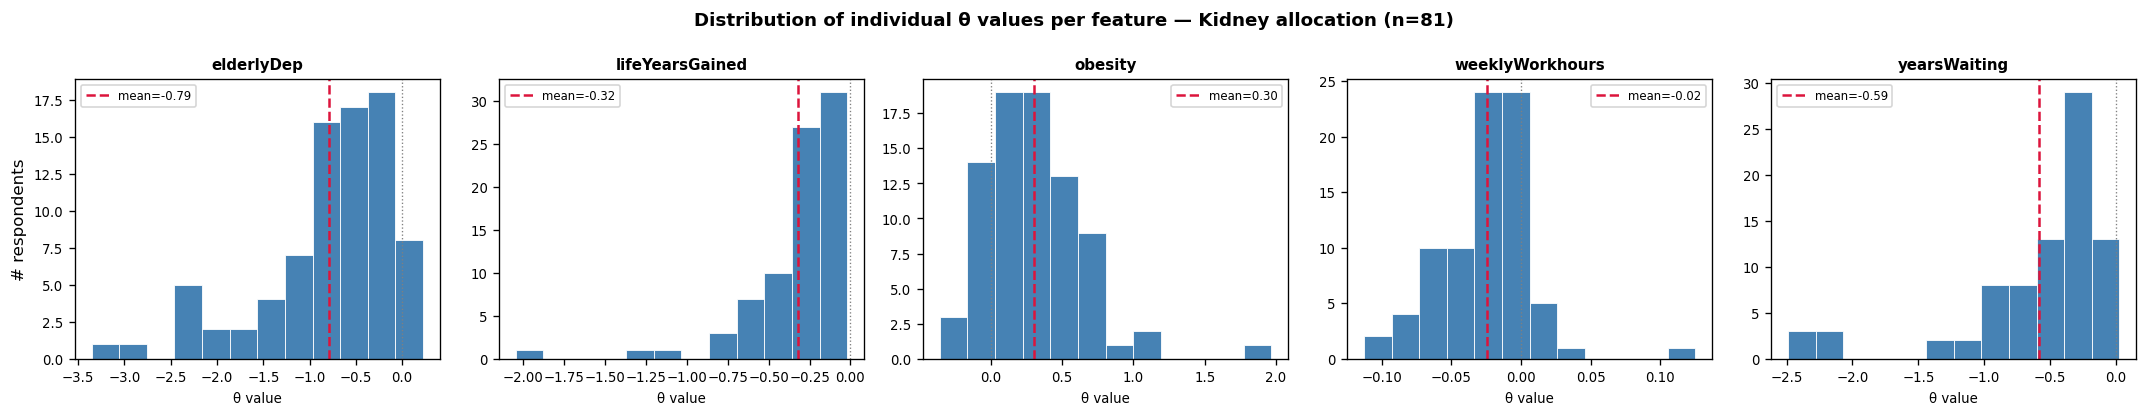

In [23]:
# ── Histogram of θ values per feature ────────────────────────────────────
fig, axes = plt.subplots(1, len(FEAT_COLS), figsize=(18, 3.5))

for ax, feat in zip(axes, FEAT_COLS):
    vals = theta_df[feat].values
    ax.hist(vals, bins=12, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(vals.mean(), color='crimson', lw=1.5, ls='--',
               label=f'mean={vals.mean():.2f}')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(feat, fontweight='bold', fontsize=9)
    ax.set_xlabel('θ value', fontsize=8)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=7)

axes[0].set_ylabel('# respondents')
plt.suptitle(f'Distribution of individual θ values per feature — Kidney allocation (n={len(theta_df)})',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

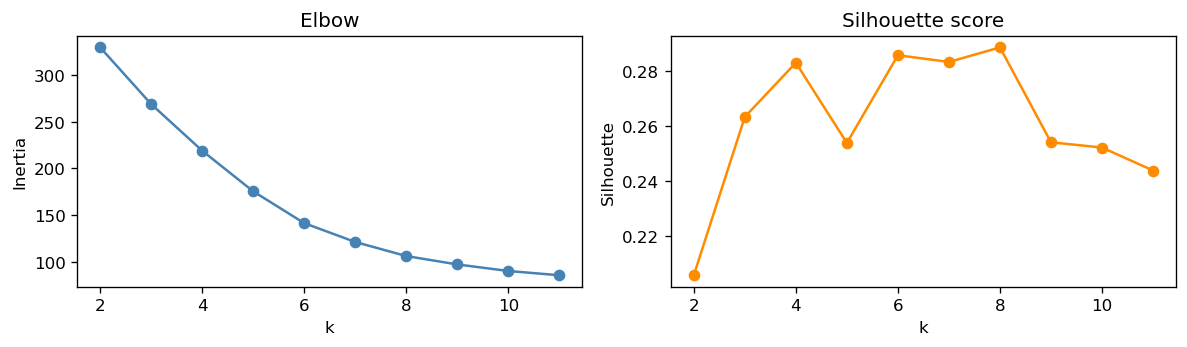

In [24]:
# ── K-means sweep to choose k ────────────────────────────────────────────
theta_mat = theta_df[FEAT_COLS].values
theta_std = (theta_mat - theta_mat.mean(0)) / (theta_mat.std(0) + 1e-10)

K_RANGE = range(2, 12)
inertias, silhouettes = [], []

from sklearn.metrics import silhouette_score

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(theta_std)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(theta_std, labels))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow')
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='darkorange')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette score')
plt.tight_layout(); plt.show()

In [25]:
# ── Choose k and cluster ─────────────────────────────────────────────────
best_k = 4   # <── adjust after inspecting elbow/silhouette

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
theta_df['cluster'] = km_final.fit_predict(theta_std)

# Map each row to its cluster
id_to_cluster = theta_df['cluster'].to_dict()
df_elig = df_elig.copy()
df_elig['cluster'] = df_elig['id'].map(id_to_cluster)

# ── Per-cluster BTL fits ──────────────────────────────────────────────────
group_arr    = df_elig['cluster'].values.astype(int)
theta_groups = []
group_weights = []
N_total = len(alpha_all)

print(f"Cluster BTL thetas (k={best_k}):")
for g in range(best_k):
    mask   = group_arr == g
    a_g, y_g = alpha_all[mask], y_all[mask]
    theta_g  = fit_btl(a_g, y_g)
    theta_groups.append(theta_g)
    group_weights.append(mask.sum() / N_total)
    print(f"  cluster {g} ({mask.sum()} obs, w={mask.sum()/N_total:.3f}): "
          + "  ".join(f"{f}={v:+.3f}" for f, v in zip(FEAT_COLS, theta_g)))

group_weights = np.array(group_weights)
theta_clust_wt = group_weights @ np.array(theta_groups)  # (k,)

# ── Pooled (RLHF) theta ───────────────────────────────────────────────────
theta_hat = fit_btl(alpha_all, y_all)
print(f"\nPooled θ̂ (all {N_total} obs):")
print(pd.Series(theta_hat, index=FEAT_COLS).round(4).to_string())
print(f"\nWeighted θ̄_clust:")
print(pd.Series(theta_clust_wt, index=FEAT_COLS).round(4).to_string())

Cluster BTL thetas (k=4):
  cluster 0 (1226 obs, w=0.037): elderlyDep=-0.778  lifeYearsGained=-1.330  obesity=+0.280  weeklyWorkhours=+0.047  yearsWaiting=-0.368
  cluster 1 (7059 obs, w=0.214): elderlyDep=-1.618  lifeYearsGained=-0.197  obesity=+0.104  weeklyWorkhours=-0.011  yearsWaiting=-0.317
  cluster 2 (22037 obs, w=0.667): elderlyDep=-0.357  lifeYearsGained=-0.175  obesity=+0.246  weeklyWorkhours=-0.022  yearsWaiting=-0.297
  cluster 3 (2700 obs, w=0.082): elderlyDep=-0.589  lifeYearsGained=-0.234  obesity=+0.104  weeklyWorkhours=-0.016  yearsWaiting=-1.682

Pooled θ̂ (all 33022 obs):
elderlyDep        -0.5285
lifeYearsGained   -0.1620
obesity            0.1882
weeklyWorkhours   -0.0166
yearsWaiting      -0.3129

Weighted θ̄_clust:
elderlyDep        -0.6614
lifeYearsGained   -0.2271
obesity            0.2054
weeklyWorkhours   -0.0169
yearsWaiting      -0.4168


In [26]:
def make_uniform_qdep_kidney(feat_cols=FEAT_COLS, n_sample=5000, seed=0):
    """
    Random alpha vectors from the discrete feature value space.
    Draws L and R independently from observed value sets, returns L - R.
    Excludes zero-alpha rows (identical pairs).
    """
    feat_vals = {
        'elderlyDep':      [0, 1, 2, 3],
        'lifeYearsGained': [-1, 5, 10, 15, 20, 25],
        'obesity':         [0, 1, 2, 3, 4],
        'weeklyWorkhours': [0, 10, 20, 30, 40, 50],
        'yearsWaiting':    [1, 3, 5, 7],
    }
    rng = np.random.default_rng(seed)
    rows = []
    while len(rows) < n_sample:
        l = np.array([rng.choice(feat_vals[f]) for f in feat_cols], dtype=float)
        r = np.array([rng.choice(feat_vals[f]) for f in feat_cols], dtype=float)
        a = l - r
        if np.any(a != 0):
            rows.append(a)
    return np.array(rows)


def compute_welfare_and_externalities(alpha, y, group, theta_groups, theta_hat,
                                       weights, q_dep=None, n_deploy=5000, seed=42):
    """
    Welfare (eq. 6):   W_g = E_z[ 2(α^T θ_g)(σ(α^T θ̂) − ½) ]
    Externality (eq. 16-17): Γ_{g,z} = (σ(α^T θ_g) − σ(α^T θ̂)) · (α^T η)
    """
    rng = np.random.default_rng(seed)
    k_dim = alpha.shape[1]
    G = len(theta_groups)

    theta_bar = weights @ np.array(theta_groups)

    if q_dep is None or q_dep == 'empirical':
        idx = rng.choice(len(alpha), size=min(n_deploy, len(alpha)), replace=False)
        A = alpha[idx]
        label = f'empirical ({len(A)} queries)'
    elif q_dep == 'uniform':
        A = make_uniform_qdep_kidney()
        label = f'uniform random ({len(A)} queries)'
    else:
        A = np.asarray(q_dep)
        label = f'custom ({len(A)} queries)'

    sig_hat = sigmoid(A @ theta_hat)
    v_hat   = sig_hat * (1 - sig_hat)
    sig_opt = sigmoid(A @ theta_bar)

    results = []
    for g in range(G):
        logits_g = A @ theta_groups[g]
        w_ideal  = 0.5 * np.abs(logits_g).mean()
        w_opt    = (logits_g * (sig_opt - 0.5)).mean()
        w_rlhf   = (logits_g * (sig_hat - 0.5)).mean()
        results.append({'cluster': g, 'weight': weights[g],
                        'W_ideal': w_ideal, 'W_opt': w_opt, 'W_rlhf': w_rlhf,
                        'rlhf_ratio':  w_rlhf / w_opt   if abs(w_opt)   > 1e-10 else np.nan,
                        'total_ratio': w_rlhf / w_ideal  if abs(w_ideal) > 1e-10 else np.nan})
    welfare_df = pd.DataFrame(results)

    # Fisher info J at θ̂ (training)
    v_train = sigmoid(alpha @ theta_hat) * (1 - sigmoid(alpha @ theta_hat))
    J     = (alpha * v_train[:, None]).T @ alpha / len(alpha)
    J_inv = np.linalg.inv(J + 1e-6 * np.eye(k_dim))

    welfare_grad = (A * ((A @ theta_bar) * v_hat)[:, None]).mean(axis=0)
    eta = J_inv @ welfare_grad

    adot = A @ eta
    gamma_mat = np.column_stack([
        (sigmoid(A @ theta_groups[g]) - sig_hat) * adot for g in range(G)
    ])

    return dict(welfare_df=welfare_df, gamma_mat=gamma_mat, eta=eta,
                J_inv=J_inv, A=A, sig_hat=sig_hat, theta_bar=theta_bar, label=label)


print("── q_dep = empirical ──")
res_emp = compute_welfare_and_externalities(
    alpha_all, y_all, group_arr, theta_groups, theta_hat, group_weights, q_dep='empirical')
print(f"  {res_emp['label']}")
print(res_emp['welfare_df'].round(4).to_string(index=False))

print("\n── q_dep = uniform ──")
res_uni = compute_welfare_and_externalities(
    alpha_all, y_all, group_arr, theta_groups, theta_hat, group_weights, q_dep='uniform')
print(f"  {res_uni['label']}")
print(res_uni['welfare_df'].round(4).to_string(index=False))

── q_dep = empirical ──
  empirical (5000 queries)
 cluster  weight  W_ideal  W_opt  W_rlhf  rlhf_ratio  total_ratio
       0  0.0371  12.2659 9.5620  8.4472      0.8834       0.6887
       1  0.2138   2.8737 2.2463  2.0876      0.9294       0.7264
       2  0.6673   1.9194 1.6729  1.5381      0.9194       0.8014
       3  0.0818   4.8504 3.2753  3.0544      0.9326       0.6297

── q_dep = uniform ──
  uniform random (5000 queries)
 cluster  weight  W_ideal   W_opt  W_rlhf  rlhf_ratio  total_ratio
       0  0.0371  13.5907 10.7799  9.6748      0.8975       0.7119
       1  0.2138   3.0295  2.4343  2.2705      0.9327       0.7495
       2  0.6673   2.0697  1.8229  1.6866      0.9252       0.8149
       3  0.0818   5.0709  3.5861  3.3284      0.9281       0.6564


In [27]:
# ── Query contentiousness (using empirical alpha_all) ────────────────────
from itertools import combinations

A_cont = alpha_all
sig_hat_cont = sigmoid(A_cont @ theta_hat)
adot_cont = A_cont @ res_emp['eta']

gamma_per_query = np.column_stack([
    (sigmoid(A_cont @ theta_groups[g]) - sig_hat_cont) * adot_cont
    for g in range(best_k)
])  # (Q, G)

disagreement   = np.abs(sigmoid(A_cont @ np.array(theta_groups).T) -
                        sig_hat_cont[:, None]).max(axis=1)
alpha_dot_eta  = np.abs(adot_cont)
max_abs_gamma  = np.abs(gamma_per_query).max(axis=1)

def label_alpha(a, feat_cols=FEAT_COLS):
    parts = [f"{f}:{v:+g}" for f, v in zip(feat_cols, a) if v != 0]
    return ', '.join(parts) if parts else 'zero'

top_idx = np.argsort(-max_abs_gamma)[:10]
print("Top-10 most contentious queries (by max |Γ|):")
print(f"{'rank':>4}  {'disagreement':>13}  {'|α·η|':>8}  {'max|Γ|':>8}  alpha")
for rank, i in enumerate(top_idx, 1):
    print(f"{rank:4d}  {disagreement[i]:13.4f}  {alpha_dot_eta[i]:8.4f}  "
          f"{max_abs_gamma[i]:8.4f}  {label_alpha(A_cont[i])}")

Top-10 most contentious queries (by max |Γ|):
rank   disagreement     |α·η|    max|Γ|  alpha
   1         0.9296    4.9622    4.6127  elderlyDep:+3, lifeYearsGained:+20, obesity:-2, weeklyWorkhours:+30, yearsWaiting:-6
   2         0.9395    4.5023    4.2297  elderlyDep:+2, lifeYearsGained:+20, obesity:-3, weeklyWorkhours:+30, yearsWaiting:-6
   3         0.9260    4.5445    4.2081  elderlyDep:-3, lifeYearsGained:-20, obesity:-1, weeklyWorkhours:-40, yearsWaiting:+6
   4         0.9319    4.4237    4.1224  elderlyDep:-3, lifeYearsGained:-20, obesity:+1, weeklyWorkhours:-10, yearsWaiting:+6
   5         0.9602    4.2698    4.0997  elderlyDep:+2, lifeYearsGained:-5, obesity:-4, weeklyWorkhours:+50, yearsWaiting:+6
   6         0.9364    4.3060    4.0323  elderlyDep:+2, lifeYearsGained:+20, obesity:-2, weeklyWorkhours:+30, yearsWaiting:-6
   7         0.9589    4.1408    3.9706  elderlyDep:-3, lifeYearsGained:+5, weeklyWorkhours:-50, yearsWaiting:-6
   8         0.9443    4.1697    3.9376

In [28]:
# ── Definition 27 Distortion ─────────────────────────────────────────────
def compute_distortion(theta_agents, lambdas, alpha_queries, weights=None):
    """
    Dist(µ_λ; θ) = W*(θ) / E[W(µ_λ(θ))]
    theta_agents  : (N, k)  reported preference vectors
    lambdas       : (N,)    mechanism weights (need not sum to 1)
    alpha_queries : (Q, k)  deployment query vectors
    weights       : (N,)    social welfare weights (default: uniform)
    """
    theta_agents  = np.array(theta_agents,  dtype=float)
    lambdas       = np.array(lambdas,       dtype=float)
    alpha_queries = np.array(alpha_queries, dtype=float)
    N, k = theta_agents.shape

    if weights is None:
        weights = np.ones(N) / N
    weights = np.array(weights, dtype=float) / np.array(weights, dtype=float).sum()
    lambdas = lambdas / lambdas.sum()

    theta_bar  = weights @ theta_agents                                             # (k,)
    signs_n    = np.sign(alpha_queries @ theta_agents.T)                           # (Q, N)
    psi_n_star = (signs_n[:, :, None] * alpha_queries[:, None, :]).mean(axis=0)   # (N, k)
    psi_sp     = lambdas @ psi_n_star                                              # (k,)
    psi_star   = (np.sign(alpha_queries @ theta_bar)[:, None] * alpha_queries).mean(axis=0)
    W_star     = 0.5 * float(theta_bar @ psi_star)
    W_sp       = 0.5 * float(theta_bar @ psi_sp)
    distortion = W_star / W_sp if W_sp > 1e-12 else np.inf

    return dict(distortion=distortion, W_star=W_star, W_sp=W_sp,
                psi_star=psi_star, psi_sp=psi_sp,
                psi_n_star=psi_n_star, theta_bar=theta_bar)


# ── Lambda choices ────────────────────────────────────────────────────────
theta_agents = np.array(theta_groups)   # (K, 5)  cluster thetas
w_agents     = group_weights            # training-obs-fraction weights
N_ag = len(theta_agents)

lam_uniform = np.ones(N_ag) / N_ag
lam_welfare = w_agents.copy()

res_tmp = compute_distortion(theta_agents, lam_uniform, alpha_all, w_agents)
n_star  = int(np.argmax(res_tmp['theta_bar'] @ res_tmp['psi_n_star'].T))
lam_opt = np.zeros(N_ag); lam_opt[n_star] = 1.0

print('=== Distortion (Definition 27) — Kidney Allocation, k-means clusters ===')
print(f'N agents: {N_ag}  |  k features: {theta_agents.shape[1]}')
print()

for q_label, A_dep in [
    ('empirical q_dep ', alpha_all),
    ('uniform q_dep   ', make_uniform_qdep_kidney()),
]:
    print(f'── {q_label} ──')
    for lbl, lam in [
        ('Uniform λ (egalitarian)    ', lam_uniform),
        ('Welfare-weighted λ         ', lam_welfare),
        ('Welfare-maximising λ (dict)', lam_opt),
    ]:
        r = compute_distortion(theta_agents, lam, A_dep, w_agents)
        print(f'  {lbl}  W*={r["W_star"]:.4f}  E[W_sp]={r["W_sp"]:.4f}  '
              f'Dist={r["distortion"]:.4f}')
    print()

# ── Per-cluster welfare contribution ─────────────────────────────────────
r0 = compute_distortion(theta_agents, lam_uniform, alpha_all, w_agents)
agent_w = r0['theta_bar'] @ r0['psi_n_star'].T
print('theta_bar^T psi_n* per cluster (empirical q_dep):')
for g, (val, wt) in enumerate(zip(agent_w, w_agents)):
    print(f'  cluster {g}  (w={wt:.3f}): {val:.4f}')
print(f'\nWelfare-maximising dictator: cluster {n_star}  '
      f'W={agent_w[n_star]:.4f}  W*={r0["W_star"]:.4f}')

=== Distortion (Definition 27) — Kidney Allocation, k-means clusters ===
N agents: 4  |  k features: 5

── empirical q_dep  ──
  Uniform λ (egalitarian)      W*=2.5105  E[W_sp]=2.2504  Dist=1.1155
  Welfare-weighted λ           W*=2.5105  E[W_sp]=2.3874  Dist=1.0516
  Welfare-maximising λ (dict)  W*=2.5105  E[W_sp]=2.4869  Dist=1.0095

── uniform q_dep    ──
  Uniform λ (egalitarian)      W*=2.7326  E[W_sp]=2.4386  Dist=1.1206
  Welfare-weighted λ           W*=2.7326  E[W_sp]=2.5970  Dist=1.0522
  Welfare-maximising λ (dict)  W*=2.7326  E[W_sp]=2.7058  Dist=1.0099

theta_bar^T psi_n* per cluster (empirical q_dep):
  cluster 0  (w=0.037): 2.2911
  cluster 1  (w=0.214): 2.2526
  cluster 2  (w=0.667): 2.4869
  cluster 3  (w=0.082): 1.9710

Welfare-maximising dictator: cluster 2  W=2.4869  W*=2.5105


In [29]:
# ── Distortion: all 81 individuals as agents ─────────────────────────────
# Each eligible respondent's personal BTL theta is a distinct agent.
# Welfare weights = fraction of training observations from that person.

person_ids_list = theta_df.index.tolist()
theta_indiv     = theta_df[FEAT_COLS].values          # (81, 5)

obs_counts = df_elig.groupby('id').size()
w_indiv    = np.array([obs_counts[pid] for pid in person_ids_list], dtype=float)
w_indiv   /= w_indiv.sum()

N_indiv = len(theta_indiv)

lam_uni_i = np.ones(N_indiv) / N_indiv
lam_wt_i  = w_indiv.copy()

res_tmp_i = compute_distortion(theta_indiv, lam_uni_i, alpha_all, w_indiv)
n_star_i  = int(np.argmax(res_tmp_i['theta_bar'] @ res_tmp_i['psi_n_star'].T))
lam_opt_i = np.zeros(N_indiv); lam_opt_i[n_star_i] = 1.0

print(f'=== Distortion (Definition 27) — Kidney, {N_indiv} individuals ===')
print()

for q_label, A_dep in [
    ('empirical q_dep ', alpha_all),
    ('uniform q_dep   ', make_uniform_qdep_kidney()),
]:
    print(f'── {q_label} ──')
    for lbl, lam in [
        ('Uniform λ (egalitarian)    ', lam_uni_i),
        ('Welfare-weighted λ         ', lam_wt_i),
        ('Welfare-maximising λ (dict)', lam_opt_i),
    ]:
        r = compute_distortion(theta_indiv, lam, A_dep, w_indiv)
        print(f'  {lbl}  W*={r["W_star"]:.4f}  E[W_sp]={r["W_sp"]:.4f}  '
              f'Dist={r["distortion"]:.4f}')
    print()

# ── Per-person welfare contribution (top/bottom 5) ────────────────────────
r0i = compute_distortion(theta_indiv, lam_uni_i, alpha_all, w_indiv)
person_w = r0i['theta_bar'] @ r0i['psi_n_star'].T   # (81,)

contrib_df = pd.DataFrame({
    'id':     person_ids_list,
    'weight': w_indiv,
    'theta_bar_dot_psi_n': person_w,
}).sort_values('theta_bar_dot_psi_n', ascending=False)

print('Top-5 highest θ̄·ψ_n* individuals:')
print(contrib_df.head(5).to_string(index=False))
print('\nBottom-5:')
print(contrib_df.tail(5).to_string(index=False))
print(f'\nWelfare-maximising dictator: id={person_ids_list[n_star_i]}  '
      f'W={person_w[n_star_i]:.4f}  W*={r0i["W_star"]:.4f}')

=== Distortion (Definition 27) — Kidney, 81 individuals ===

── empirical q_dep  ──
  Uniform λ (egalitarian)      W*=3.8569  E[W_sp]=3.2163  Dist=1.1992
  Welfare-weighted λ           W*=3.8569  E[W_sp]=3.3082  Dist=1.1659
  Welfare-maximising λ (dict)  W*=3.8569  E[W_sp]=3.8388  Dist=1.0047

── uniform q_dep    ──
  Uniform λ (egalitarian)      W*=4.2023  E[W_sp]=3.5310  Dist=1.1901
  Welfare-weighted λ           W*=4.2023  E[W_sp]=3.6373  Dist=1.1553
  Welfare-maximising λ (dict)  W*=4.2023  E[W_sp]=4.1826  Dist=1.0047

Top-5 highest θ̄·ψ_n* individuals:
 id   weight  theta_bar_dot_psi_n
 70 0.007268             3.838758
 19 0.016353             3.818790
 46 0.018079             3.813078
 52 0.014082             3.786019
 45 0.009085             3.770221

Bottom-5:
 id   weight  theta_bar_dot_psi_n
 34 0.005451             2.172062
  6 0.018170             2.161321
  2 0.003634             2.154936
 80 0.005451             2.074363
 39 0.002029             1.792663

Welfare-maximisi

In [30]:
# # ── Distortion vs. # clusters (uniform λ) ────────────────────────────────
# K_SWEEP = [4, 10, 20, 30, 40, 50, 60, 70, 81]

# A_emp = alpha_all
# A_uni = make_uniform_qdep_kidney()

# person_ids_arr = np.array(theta_df.index.tolist())   # (81,) ordered

# results_sweep = []
# for k in K_SWEEP:
#     if k < 81:
#         km = KMeans(n_clusters=k, random_state=42, n_init=10)
#         person_labels = km.fit_predict(theta_std)   # (81,) — one label per person

#         # map each observation row to its person's cluster
#         id_to_cluster = {pid: person_labels[i] for i, pid in enumerate(person_ids_arr)}
#         row_clusters  = df_elig['id'].map(id_to_cluster).values.astype(int)  # (33022,)

#         th_agents, wts = [], []
#         for g in range(k):
#             mask = row_clusters == g
#             th_agents.append(fit_btl(alpha_all[mask], y_all[mask]))
#             wts.append(mask.sum() / len(alpha_all))
#         th_agents = np.array(th_agents)
#         wts = np.array(wts)
#     else:
#         th_agents = theta_df[FEAT_COLS].values
#         obs_cnt = df_elig.groupby('id').size()
#         wts = np.array([obs_cnt[pid] for pid in theta_df.index], dtype=float)
#         wts /= wts.sum()

#     lam = np.ones(k) / k

#     r_emp = compute_distortion(th_agents, lam, A_emp, wts)
#     r_uni = compute_distortion(th_agents, lam, A_uni, wts)
#     results_sweep.append({'k': k, 'dist_emp': r_emp['distortion'],
#                           'dist_uni': r_uni['distortion']})
#     print(f"k={k:3d}  emp={r_emp['distortion']:.4f}  uni={r_uni['distortion']:.4f}")

# sweep_df = pd.DataFrame(results_sweep)

# fig, ax = plt.subplots(figsize=(8, 4))
# ax.plot(sweep_df['k'], sweep_df['dist_emp'], 'o-', label='Empirical q_dep', color='steelblue')
# ax.plot(sweep_df['k'], sweep_df['dist_uni'], 's-', label='Uniform q_dep',   color='darkorange')
# ax.axhline(1.0, color='grey', ls='--', lw=0.8)
# ax.set_xlabel('Number of agents (k-means clusters → 81 individuals)')
# ax.set_ylabel('Distortion  W* / E[W_sp]')
# ax.set_title('Distortion vs. granularity of agent representation (uniform λ)')
# ax.set_xticks(sweep_df['k'])
# ax.legend()
# plt.tight_layout()
# plt.show()

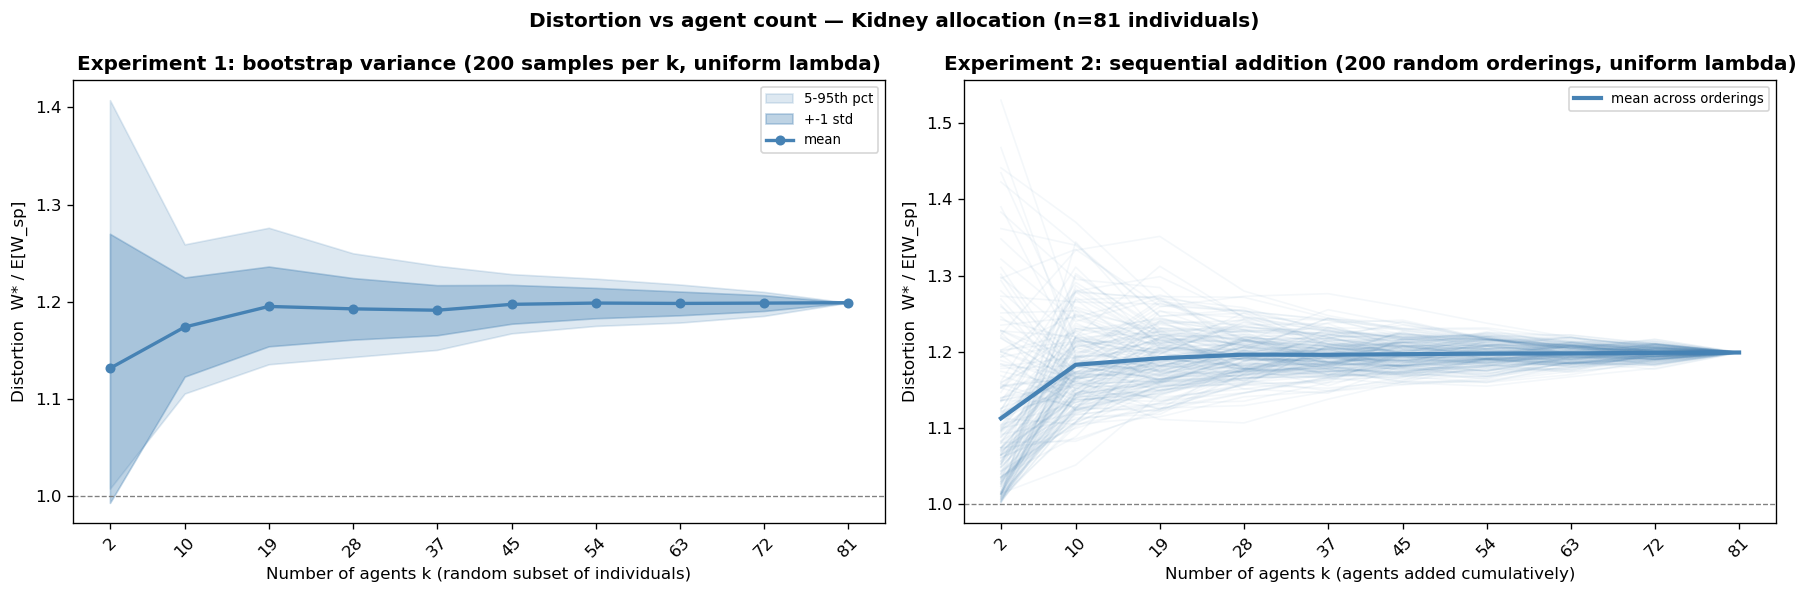

K values used: [2, 10, 19, 28, 37, 45, 54, 63, 72, 81]
Bootstrap: k=2  -> 1.132 +/- 0.138
Bootstrap: k=81 -> 1.199 +/- 0.0000


In [42]:
# ── Distortion bootstrap & sequential addition — Kidney (81 individuals) ──
# Uses 20 evenly-spaced group sizes from 2 → 81 (≈ N/20 increments).
#
# Experiment 1 (bootstrap variance):
#   For each k in K_vals, draw 500 random k-subsets → compute distortion.
#
# Experiment 2 (sequential addition):
#   Shuffle 81 agents into a random order, compute distortion at each step.
#   Repeat 200 orderings; only record at the same 20 k values.

theta_arr_k = theta_df[FEAT_COLS].values          # (81, 5)
obs_cnt_k   = df_elig.groupby('id').size()
w_arr_k     = np.array([obs_cnt_k[pid] for pid in theta_df.index], dtype=float)
w_arr_k    /= w_arr_k.sum()
N_ag_k      = len(theta_arr_k)

K_vals_k  = np.unique(np.linspace(2, N_ag_k, 10).astype(int)).tolist()
N_BOOT_K  = 200
N_ORDER_K = 200
A_dep_k   = alpha_all.astype(float)

rng_k = np.random.default_rng(1)

# ── Experiment 1: bootstrap variance ─────────────────────────────────────
boot_means_k, boot_stds_k, boot_p5_k, boot_p95_k = [], [], [], []

for k in K_vals_k:
    dists = []
    for _ in range(N_BOOT_K):
        idx   = rng_k.choice(N_ag_k, size=k, replace=False)
        th_k  = theta_arr_k[idx]
        w_k   = w_arr_k[idx]; w_k = w_k / w_k.sum()
        lam_k = np.ones(k) / k
        r     = compute_distortion(th_k, lam_k, A_dep_k, w_k)
        dists.append(r['distortion'])
    dists = np.array(dists)
    boot_means_k.append(dists.mean())
    boot_stds_k.append(dists.std())
    boot_p5_k.append(np.percentile(dists, 5))
    boot_p95_k.append(np.percentile(dists, 95))

boot_means_k = np.array(boot_means_k)
boot_stds_k  = np.array(boot_stds_k)
boot_p5_k    = np.array(boot_p5_k)
boot_p95_k   = np.array(boot_p95_k)

# ── Experiment 2: sequential addition ────────────────────────────────────
K_set = set(K_vals_k)
seq_all_k = []

for _ in range(N_ORDER_K):
    order = rng_k.permutation(N_ag_k)
    path  = []
    for k in K_vals_k:
        idx   = order[:k]
        th_k  = theta_arr_k[idx]
        w_k   = w_arr_k[idx]; w_k = w_k / w_k.sum()
        lam_k = np.ones(k) / k
        r     = compute_distortion(th_k, lam_k, A_dep_k, w_k)
        path.append(r['distortion'])
    seq_all_k.append(path)

seq_all_k  = np.array(seq_all_k)    # (N_ORDER_K, 20)
seq_mean_k = seq_all_k.mean(axis=0)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.fill_between(K_vals_k, boot_p5_k, boot_p95_k,
                alpha=0.18, color='steelblue', label='5-95th pct')
ax.fill_between(K_vals_k, boot_means_k - boot_stds_k, boot_means_k + boot_stds_k,
                alpha=0.35, color='steelblue', label='+-1 std')
ax.plot(K_vals_k, boot_means_k, 'o-', color='steelblue', lw=2, ms=5, label='mean')
ax.axhline(1.0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Number of agents k (random subset of individuals)')
ax.set_ylabel('Distortion  W* / E[W_sp]')
ax.set_title('Experiment 1: bootstrap variance' + f' ({N_BOOT_K} samples per k, uniform lambda)',
             fontweight='bold')
ax.set_xticks(K_vals_k); ax.tick_params(axis='x', labelrotation=45)
ax.legend(fontsize=8)

ax = axes[1]
for path in seq_all_k:
    ax.plot(K_vals_k, path, color='steelblue', alpha=0.06, lw=1)
ax.plot(K_vals_k, seq_mean_k, color='steelblue', lw=2.5, label='mean across orderings')
ax.axhline(1.0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Number of agents k (agents added cumulatively)')
ax.set_ylabel('Distortion  W* / E[W_sp]')
ax.set_title('Experiment 2: sequential addition' + f' ({N_ORDER_K} random orderings, uniform lambda)',
             fontweight='bold')
ax.set_xticks(K_vals_k); ax.tick_params(axis='x', labelrotation=45)
ax.legend(fontsize=8)

plt.suptitle('Distortion vs agent count — Kidney allocation (n=81 individuals)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print(f"K values used: {K_vals_k}")
print(f"Bootstrap: k=2  -> {boot_means_k[0]:.3f} +/- {boot_stds_k[0]:.3f}")
print(f"Bootstrap: k={K_vals_k[-1]} -> {boot_means_k[-1]:.3f} +/- {boot_stds_k[-1]:.4f}")


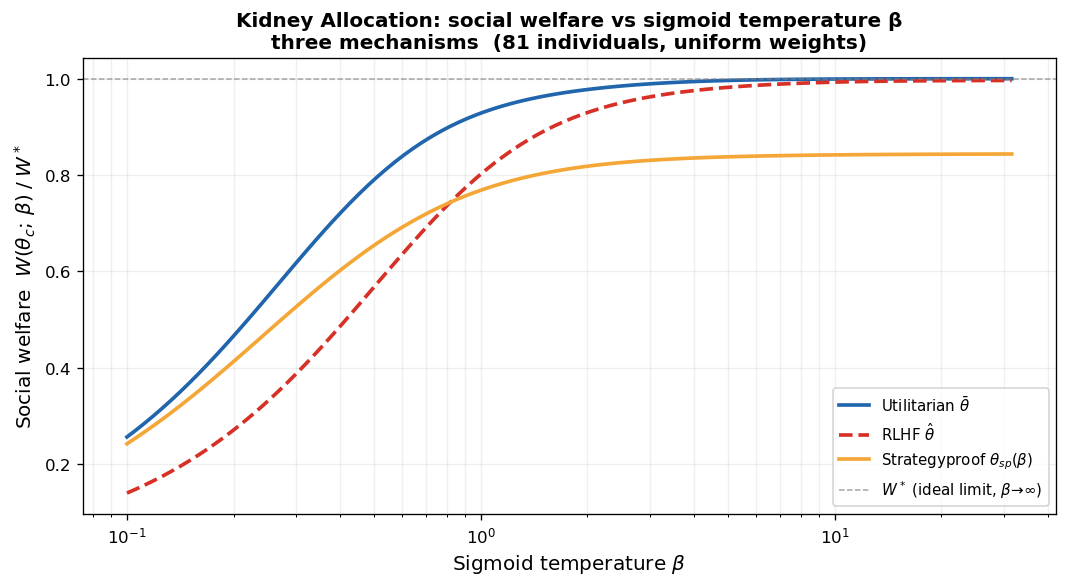

W* (utilitarian boundary optimal): 3.4928


In [32]:
# ── Social welfare vs sigmoid temperature β — Kidney ─────────────────────
#
# W(θ_c; β) = Σ_n w_n · E_z[ 2(α·θ_n)(σ(β·α·θ_c) − 0.5) ]
# Normalized by W* = E_z[|α·θ̄|].
# Three mechanisms: utilitarian θ̄, RLHF θ̂, strategyproof θ_sp(β).
#
# θ_sp(β) = Φ⁻¹( (1/N) Σ_i Φ(θ_i; β) )
# where Φ(θ; β) = E_z[ 2(σ(β·α^T θ) − 0.5) · α ]

from scipy.special import expit
from scipy.optimize import minimize

theta_arr  = theta_df[FEAT_COLS].values.astype(float)   # (81, 5)
N_agents   = len(theta_arr)
w_uniform  = np.ones(N_agents) / N_agents
theta_bar  = w_uniform @ theta_arr
theta_rlhf = theta_hat

def phi_all(theta_agents, beta, alpha):
    """Impact vectors for all agents at once. Returns (N, k)."""
    logits = alpha @ theta_agents.T                        # (Q, N)
    factor = (expit(beta * logits) - 0.5)             # (Q, N)
    return factor.T @ alpha / len(alpha)                   # (N, k)

def phi_inv(target, beta, alpha, theta_init=None):
    """Find θ s.t. Φ(θ; β) ≈ target via L-BFGS-B."""
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def social_welfare_beta(theta_deploy, beta, theta_agents, weights, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return float(weights @ (alpha @ theta_agents.T * factor[:, None]).mean(axis=0))

psi_star = (np.sign(alpha_all @ theta_bar)[:, None] * alpha_all).mean(axis=0)
W_star   = 0.5 * float(theta_bar @ psi_star)

betas = np.logspace(-1, 1.5, 100)

W_util_sw, W_rlhf_sw, W_sp_sw = [], [], []
theta_sp_prev = theta_bar.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr, b, alpha_all).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_all, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    W_util_sw.append(social_welfare_beta(theta_bar,  b, theta_arr, w_uniform, alpha_all))
    W_rlhf_sw.append(social_welfare_beta(theta_rlhf, b, theta_arr, w_uniform, alpha_all))
    W_sp_sw.append(  social_welfare_beta(theta_sp,   b, theta_arr, w_uniform, alpha_all))

W_util_sw = np.array(W_util_sw) / W_star
W_rlhf_sw = np.array(W_rlhf_sw) / W_star
W_sp_sw   = np.array(W_sp_sw)   / W_star

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, W_util_sw, color='#2166ac', ls='-',  lw=2.2, label=r'Utilitarian $\bar\theta$')
ax.plot(betas, W_rlhf_sw, color='#d73027', ls='--', lw=2.2, label=r'RLHF $\hat\theta$')
ax.plot(betas, W_sp_sw,   color='#f4a736', ls='-',  lw=2.2, label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.axhline(1.0, color='grey', ls='--', lw=0.9, alpha=0.7,
           label=r'$W^*$ (ideal limit, $\beta\to\infty$)')
ax.set_xscale('log')
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel(r'Social welfare  $W(\theta_c;\,\beta)\;/\;W^*$', fontsize=12)
ax.set_title('Kidney Allocation: social welfare vs sigmoid temperature β\n'
             'three mechanisms  (81 individuals, uniform weights)',
             fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

print(f"W* (utilitarian boundary optimal): {W_star:.4f}")


In [ ]:
# ── Per-person welfare bounds vs sigmoid temperature β — Kidney ───────────
#
# For each mechanism and each β, compute W_n(θ_c(β); β) for all 81 agents,
# then take the pointwise max and min. Person identity can switch at each β.
# Three subplots: utilitarian, RLHF, strategyproof.

from scipy.special import expit
from scipy.optimize import minimize

theta_arr  = theta_df[FEAT_COLS].values.astype(float)
N_agents   = len(theta_arr)
w_uniform  = np.ones(N_agents) / N_agents
theta_bar  = w_uniform @ theta_arr
theta_rlhf = theta_hat

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

psi_star = (np.sign(alpha_all @ theta_bar)[:, None] * alpha_all).mean(axis=0)
W_star   = 0.5 * float(theta_bar @ psi_star)

betas = np.logspace(-1, 1.5, 100)

records = {lbl: {'max': [], 'min': [], 'mean': []}
           for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']}

theta_sp_prev = theta_bar.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr, b, alpha_all).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_all, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    for lbl, th_c in [('Utilitarian', theta_bar),
                      ('RLHF',        theta_rlhf),
                      ('Strategyproof', theta_sp)]:
        W_n = per_agent_welfare(th_c, b, theta_arr, alpha_all) / W_star
        records[lbl]['max'].append(W_n.max())
        records[lbl]['min'].append(W_n.min())
        records[lbl]['mean'].append(W_n.mean())

for lbl in records:
    for k in records[lbl]:
        records[lbl][k] = np.array(records[lbl][k])

mech_colors = {'Utilitarian': '#2166ac', 'RLHF': '#d73027', 'Strategyproof': '#f4a736'}
mech_titles = {
    'Utilitarian':   r'Utilitarian  $\bar\theta$',
    'RLHF':          r'RLHF  $\hat\theta$',
    'Strategyproof': r'Strategyproof  $\theta_{sp}(\beta)$',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, lbl in zip(axes, ['Utilitarian', 'RLHF', 'Strategyproof']):
    c   = mech_colors[lbl]
    rec = records[lbl]
    ax.fill_between(betas, rec['min'], rec['max'],
                    color=c, alpha=0.18, label='worst-off to best-off range')
    ax.plot(betas, rec['max'],  color=c, lw=2.0, ls='-',  label='best-off person')
    ax.plot(betas, rec['min'],  color=c, lw=2.0, ls=':',  label='worst-off person')
    ax.plot(betas, rec['mean'], color=c, lw=1.5, ls='--', label='social welfare (mean)')
    ax.axhline(0, color='grey', lw=0.7, alpha=0.5)
    ax.set_xscale('log')
    ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=11)
    ax.set_title(mech_titles[lbl], fontweight='bold', fontsize=11)
    ax.grid(True, which='both', alpha=0.18)
    ax.legend(fontsize=8, loc='lower right')

axes[0].set_ylabel(r'Individual welfare  $W_n(\theta_c;\,\beta)\;/\;W^*$', fontsize=11)
fig.suptitle('Kidney Allocation: best-off and worst-off individual welfare vs β\n'
             '(person identity can switch at each β; shaded = full range, 81 individuals)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# ── Agent identity diagnostic: which agent is best/worst-off at each β ───
# (Kidney Allocation, 81 individuals)
from scipy.special import expit
from scipy.optimize import minimize
from collections import Counter

theta_arr  = theta_df[FEAT_COLS].values.astype(float)
N_agents   = len(theta_arr)
w_uniform  = np.ones(N_agents) / N_agents
theta_bar  = w_uniform @ theta_arr
theta_rlhf = theta_hat
agent_ids  = list(theta_df.index)   # participant IDs

def _phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def _phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def _per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

psi_star = (np.sign(alpha_all @ theta_bar)[:, None] * alpha_all).mean(axis=0)
W_star   = 0.5 * float(theta_bar @ psi_star)

betas = np.logspace(-1, 1.5, 100)

argrecords = {lbl: {'argmin': [], 'argmax': []}
              for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']}

theta_sp_prev = theta_bar.copy()
for b in betas:
    phi_avg       = _phi_all(theta_arr, b, alpha_all).mean(axis=0)
    theta_sp      = _phi_inv(phi_avg, b, alpha_all, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()
    for lbl, th_c in [('Utilitarian',   theta_bar),
                      ('RLHF',          theta_rlhf),
                      ('Strategyproof', theta_sp)]:
        W_n = _per_agent_welfare(th_c, b, theta_arr, alpha_all) / W_star
        argrecords[lbl]['argmin'].append(int(W_n.argmin()))
        argrecords[lbl]['argmax'].append(int(W_n.argmax()))

# ── Plot ──────────────────────────────────────────────────────────────────
mech_colors = {'Utilitarian': '#2166ac', 'RLHF': '#d73027', 'Strategyproof': '#f4a736'}
mech_titles = {
    'Utilitarian':   r'Utilitarian  $\bar\theta$',
    'RLHF':          r'RLHF  $\hat\theta$',
    'Strategyproof': r'Strategyproof  $\theta_{sp}(\beta)$',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

for ax, lbl in zip(axes, ['Utilitarian', 'RLHF', 'Strategyproof']):
    c        = mech_colors[lbl]
    amin_idx = argrecords[lbl]['argmin']
    amax_idx = argrecords[lbl]['argmax']

    ax.step(betas, amin_idx, where='mid', color=c, lw=2.0, ls=':', label='worst-off agent')
    ax.step(betas, amax_idx, where='mid', color=c, lw=2.0, ls='-', label='best-off agent')
    ax.scatter(betas, amin_idx, color=c, s=14, alpha=0.6, marker='v', zorder=3)
    ax.scatter(betas, amax_idx, color=c, s=14, alpha=0.6, marker='^', zorder=3)

    ax.set_xscale('log')
    ax.set_xlabel(r'$\beta$', fontsize=11)
    ax.set_title(mech_titles[lbl], fontweight='bold', fontsize=11)
    ax.grid(True, which='both', alpha=0.15)
    ax.legend(fontsize=8, loc='best')

axes[0].set_ylabel('Agent index (0-80)', fontsize=11)

fig.suptitle('Kidney Allocation: which agent is best-off / worst-off at each β\n'
             '(▲/solid = best-off, ▼/dotted = worst-off; y-axis = agent index)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("Worst-off agent (argmin) summary:")
for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']:
    idxs = argrecords[lbl]['argmin']
    ids  = [agent_ids[i] for i in idxs]
    cnt  = Counter(ids)
    top3 = sorted(cnt.items(), key=lambda x: -x[1])[:3]
    print(f"  {lbl:14s}: {top3}  (n_distinct={len(cnt)})")

print("\nBest-off agent (argmax) summary:")
for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']:
    idxs = argrecords[lbl]['argmax']
    ids  = [agent_ids[i] for i in idxs]
    cnt  = Counter(ids)
    top3 = sorted(cnt.items(), key=lambda x: -x[1])[:3]
    print(f"  {lbl:14s}: {top3}  (n_distinct={len(cnt)})")


In [ ]:
# ── Gini coefficient of per-agent welfare vs β — Kidney ──────────────────
#
# For each mechanism and each β, compute the Gini coefficient of the
# 81-agent welfare distribution W_n(θ_c(β); β).
# Values shifted to non-negative before applying the standard Gini formula.

from scipy.special import expit
from scipy.optimize import minimize

theta_arr  = theta_df[FEAT_COLS].values.astype(float)
N_agents   = len(theta_arr)
w_uniform  = np.ones(N_agents) / N_agents
theta_bar  = w_uniform @ theta_arr
theta_rlhf = theta_hat

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

def gini(values):
    v = np.array(values, dtype=float)
    v = v - v.min()
    if v.sum() < 1e-12:
        return 0.0
    v = np.sort(v)
    N = len(v)
    return float((2 * (np.arange(1, N + 1) * v).sum()) / (N * v.sum()) - (N + 1) / N)

betas = np.logspace(-1, 1.5, 100)

gini_util, gini_rlhf, gini_sp = [], [], []
theta_sp_prev = theta_bar.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr, b, alpha_all).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_all, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    W_util = per_agent_welfare(theta_bar,  b, theta_arr, alpha_all)
    W_rlhf = per_agent_welfare(theta_rlhf, b, theta_arr, alpha_all)
    W_sp   = per_agent_welfare(theta_sp,   b, theta_arr, alpha_all)

    gini_util.append(gini(W_util))
    gini_rlhf.append(gini(W_rlhf))
    gini_sp.append(  gini(W_sp))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, gini_util, color='#2166ac', lw=2.2, ls='-',
        label=r'Utilitarian $\bar\theta$')
ax.plot(betas, gini_rlhf, color='#d73027', lw=2.2, ls='--',
        label=r'RLHF $\hat\theta$')
ax.plot(betas, gini_sp,   color='#f4a736', lw=2.2, ls='-.',
        label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel('Gini coefficient of per-agent welfare', fontsize=12)
ax.set_title('Kidney Allocation: welfare inequality across agents\n'
             r'Gini coefficient vs sigmoid temperature $\beta$  (81 individuals)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

for lbl, arr in [('Utilitarian', gini_util), ('RLHF', gini_rlhf), ('SP', gini_sp)]:
    print(f'{lbl:14s}  β=0.1: {arr[0]:.3f}   β=1: {arr[np.argmin(np.abs(betas-1))]:.3f}'
          f'   β=32: {arr[-1]:.3f}')


In [ ]:
# ── Welfare variance across agents vs β — Kidney Allocation ────────────────
#
# For each mechanism and each β:
#   Var[W_n(θ_c; β)] = (1/N) Σ_n (W_n − W̄)²
# Normalized by W*² to give a dimensionless relative variance.

from scipy.special import expit
from scipy.optimize import minimize

theta_arr  = theta_df[FEAT_COLS].values.astype(float)  # (81, 5)
w_uniform  = np.ones(len(theta_arr)) / len(theta_arr)
theta_bar  = w_uniform @ theta_arr
theta_rlhf = theta_hat

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

psi_star  = (np.sign(alpha_all @ theta_bar)[:, None] * alpha_all).mean(axis=0)
W_star    = 0.5 * float(theta_bar @ psi_star)
betas     = np.logspace(-1, 1.5, 100)

var_util, var_rlhf, var_sp = [], [], []
theta_sp_prev = theta_bar.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr, b, alpha_all).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_all, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    W_util = per_agent_welfare(theta_bar,  b, theta_arr, alpha_all)
    W_rlhf = per_agent_welfare(theta_rlhf, b, theta_arr, alpha_all)
    W_sp   = per_agent_welfare(theta_sp,   b, theta_arr, alpha_all)

    W_star_sq = W_star ** 2
    var_util.append(W_util.var() / W_star_sq)
    var_rlhf.append(W_rlhf.var() / W_star_sq)
    var_sp.append(  W_sp.var()   / W_star_sq)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, var_util, color='#2166ac', lw=2.2, ls='-',
        label=r'Utilitarian $\bar\theta$')
ax.plot(betas, var_rlhf, color='#d73027', lw=2.2, ls='--',
        label=r'RLHF $\hat\theta$')
ax.plot(betas, var_sp,   color='#f4a736', lw=2.2, ls='-.',
        label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel(r'Var$[W_n / W^*]$', fontsize=12)
ax.set_title('Kidney Allocation: welfare variance across 81 agents\n'
             r'vs sigmoid temperature $\beta$', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

for lbl, arr in [('Utilitarian', var_util), ('RLHF', var_rlhf), ('SP', var_sp)]:
    print(f'{lbl:14s}  β=0.1: {arr[0]:.4f}   β=1: {arr[np.argmin(np.abs(betas-1))]:.4f}'
          f'   β=32: {arr[-1]:.4f}')


In [ ]:
# ── Standardized alpha: refit BTL models ─────────────────────────────────
#
# Divide each alpha feature column by its empirical std across the pooled
# training data before fitting BTL. This puts all five features on equal
# footing and prevents large-range features (lifeYearsGained, weeklyWorkhours)
# from dominating welfare computations.
#
# Variables produced:
#   feat_std        (5,)    per-feature std of alpha_all
#   alpha_std       (Q, 5)  standardized pooled alpha
#   theta_hat_std   (5,)    pooled BTL fit on standardized alpha
#   theta_std_df    DataFrame (81 × 5)  per-person BTL fit on standardized alpha

feat_std  = alpha_all.std(axis=0)
feat_std  = np.where(feat_std < 1e-10, 1.0, feat_std)   # avoid div-by-zero
alpha_std = alpha_all / feat_std

print("Per-feature alpha std (used for standardization):")
for f, s in zip(FEAT_COLS, feat_std):
    print(f"  {f}: {s:.4f}")

# Pooled theta on standardized alpha
theta_hat_std = fit_btl(alpha_std, y_all)

# Per-person thetas on standardized alpha
theta_std_records = []
for pid in eligible_ids:
    df_p  = df_elig[df_elig['id'] == pid]
    a, y  = build_alpha_y(df_p)
    theta = fit_btl(a / feat_std, y)
    theta_std_records.append({'id': pid, **dict(zip(FEAT_COLS, theta))})

theta_std_df = pd.DataFrame(theta_std_records).set_index('id')

print(f"\nRefitted {len(theta_std_df)} individual BTL models on standardized alpha")
print("\nPer-feature θ distribution (standardized):")
print(theta_std_df[FEAT_COLS].describe().round(4).to_string())

# ── Side-by-side theta heatmap: raw vs standardized ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, df_plot, title in [
    (axes[0], theta_df,     'Original θ (raw alpha)'),
    (axes[1], theta_std_df, 'Standardized θ (alpha ÷ std)'),
]:
    mat  = df_plot[FEAT_COLS].values
    vmax = np.abs(mat).max()
    im   = ax.imshow(mat, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(FEAT_COLS)))
    ax.set_xticklabels(FEAT_COLS, rotation=35, ha='right', fontsize=9)
    ax.set_yticks(range(len(df_plot)))
    ax.set_yticklabels(df_plot.index, fontsize=7)
    plt.colorbar(im, ax=ax, label='θ value')
    ax.set_title(title, fontweight='bold')

plt.suptitle('Kidney: individual θ heatmaps — raw vs standardized',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# How many people have at least one negative theta component (standardized)?
n_neg = (theta_std_df[FEAT_COLS].values < 0).any(axis=1).sum()
print(f"\nPeople with ≥1 negative θ component (standardized): {n_neg} / {len(theta_std_df)}")
n_neg_lyg = (theta_std_df['lifeYearsGained'] < 0).sum()
print(f"People with negative θ on lifeYearsGained: {n_neg_lyg}")


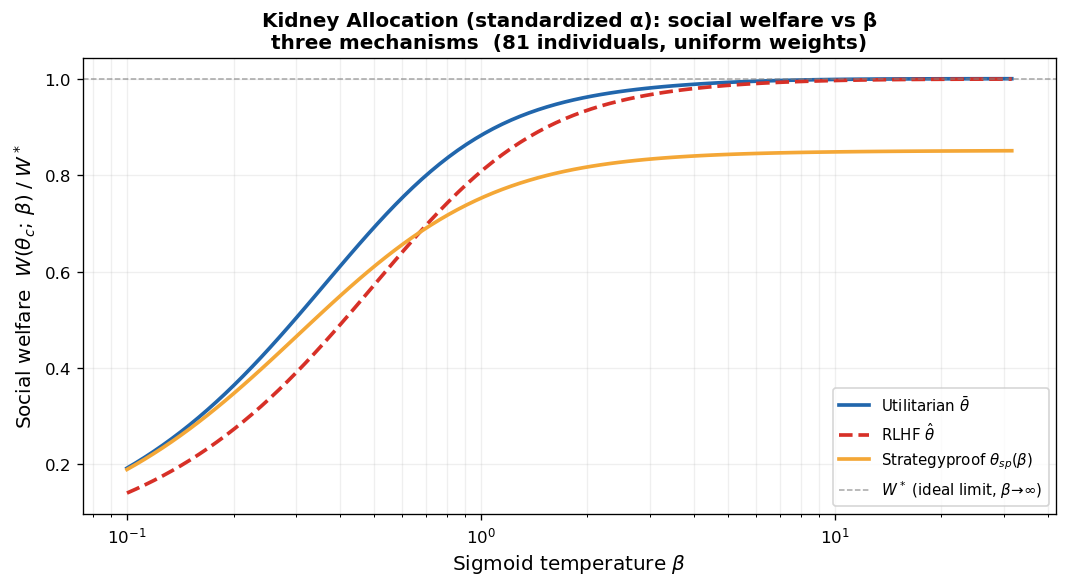

W* (standardized): 2.5547


In [36]:
# ── Social welfare vs β — Kidney (standardized alpha) ────────────────────

from scipy.special import expit
from scipy.optimize import minimize

theta_arr_s  = theta_std_df[FEAT_COLS].values.astype(float)  # (81, 5)
N_agents     = len(theta_arr_s)
w_uniform    = np.ones(N_agents) / N_agents
theta_bar_s  = w_uniform @ theta_arr_s
theta_rlhf_s = theta_hat_std

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def social_welfare_beta(theta_deploy, beta, theta_agents, weights, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return float(weights @ (alpha @ theta_agents.T * factor[:, None]).mean(axis=0))

psi_star_s = (np.sign(alpha_std @ theta_bar_s)[:, None] * alpha_std).mean(axis=0)
W_star_s   = float(theta_bar_s @ psi_star_s)

betas = np.logspace(-1, 1.5, 100)

W_util_sw, W_rlhf_sw, W_sp_sw = [], [], []
theta_sp_prev = theta_bar_s.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr_s, b, alpha_std).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_std, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()
    W_util_sw.append(social_welfare_beta(theta_bar_s,  b, theta_arr_s, w_uniform, alpha_std))
    W_rlhf_sw.append(social_welfare_beta(theta_rlhf_s, b, theta_arr_s, w_uniform, alpha_std))
    W_sp_sw.append(  social_welfare_beta(theta_sp,     b, theta_arr_s, w_uniform, alpha_std))

W_util_sw = np.array(W_util_sw) / W_star_s
W_rlhf_sw = np.array(W_rlhf_sw) / W_star_s
W_sp_sw   = np.array(W_sp_sw)   / W_star_s

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, W_util_sw, color='#2166ac', ls='-',  lw=2.2, label=r'Utilitarian $\bar\theta$')
ax.plot(betas, W_rlhf_sw, color='#d73027', ls='--', lw=2.2, label=r'RLHF $\hat\theta$')
ax.plot(betas, W_sp_sw,   color='#f4a736', ls='-',  lw=2.2, label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.axhline(1.0, color='grey', ls='--', lw=0.9, alpha=0.7,
           label=r'$W^*$ (ideal limit, $\beta\to\infty$)')
ax.set_xscale('log')
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel(r'Social welfare  $W(\theta_c;\,\beta)\;/\;W^*$', fontsize=12)
ax.set_title('Kidney Allocation (standardized α): social welfare vs β\n'
             'three mechanisms  (81 individuals, uniform weights)',
             fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()
print(f"W* (standardized): {W_star_s:.4f}")


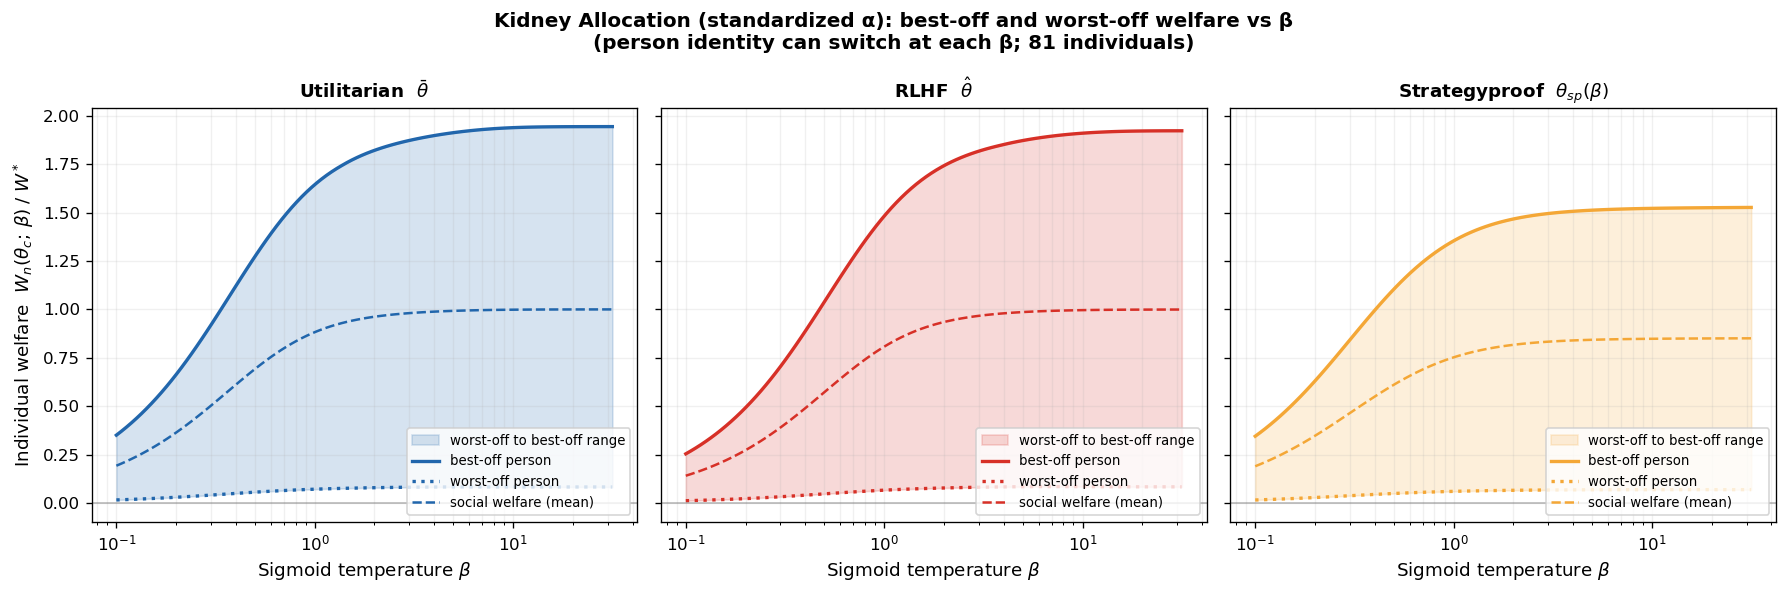

Utilitarian     min welfare at β=32: +0.0826
RLHF            min welfare at β=32: +0.0833
Strategyproof   min welfare at β=32: +0.0689


In [37]:
# ── Individual welfare bounds vs β — Kidney (standardized alpha) ──────────

from scipy.special import expit
from scipy.optimize import minimize

theta_arr_s  = theta_std_df[FEAT_COLS].values.astype(float)
N_agents     = len(theta_arr_s)
w_uniform    = np.ones(N_agents) / N_agents
theta_bar_s  = w_uniform @ theta_arr_s
theta_rlhf_s = theta_hat_std

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

psi_star_s = (np.sign(alpha_std @ theta_bar_s)[:, None] * alpha_std).mean(axis=0)
W_star_s   = float(theta_bar_s @ psi_star_s)

betas = np.logspace(-1, 1.5, 100)

records = {lbl: {'max': [], 'min': [], 'mean': []}
           for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']}

theta_sp_prev = theta_bar_s.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr_s, b, alpha_std).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_std, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    for lbl, th_c in [('Utilitarian',   theta_bar_s),
                      ('RLHF',          theta_rlhf_s),
                      ('Strategyproof', theta_sp)]:
        W_n = per_agent_welfare(th_c, b, theta_arr_s, alpha_std) / W_star_s
        records[lbl]['max'].append(W_n.max())
        records[lbl]['min'].append(W_n.min())
        records[lbl]['mean'].append(W_n.mean())

for lbl in records:
    for k in records[lbl]:
        records[lbl][k] = np.array(records[lbl][k])

mech_colors = {'Utilitarian': '#2166ac', 'RLHF': '#d73027', 'Strategyproof': '#f4a736'}
mech_titles = {
    'Utilitarian':   r'Utilitarian  $\bar\theta$',
    'RLHF':          r'RLHF  $\hat\theta$',
    'Strategyproof': r'Strategyproof  $\theta_{sp}(\beta)$',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, lbl in zip(axes, ['Utilitarian', 'RLHF', 'Strategyproof']):
    c   = mech_colors[lbl]
    rec = records[lbl]
    ax.fill_between(betas, rec['min'], rec['max'],
                    color=c, alpha=0.18, label='worst-off to best-off range')
    ax.plot(betas, rec['max'],  color=c, lw=2.0, ls='-',  label='best-off person')
    ax.plot(betas, rec['min'],  color=c, lw=2.0, ls=':',  label='worst-off person')
    ax.plot(betas, rec['mean'], color=c, lw=1.5, ls='--', label='social welfare (mean)')
    ax.axhline(0, color='grey', lw=0.9, ls='-', alpha=0.6)
    ax.set_xscale('log')
    ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=11)
    ax.set_title(mech_titles[lbl], fontweight='bold', fontsize=11)
    ax.grid(True, which='both', alpha=0.18)
    ax.legend(fontsize=8, loc='lower right')

axes[0].set_ylabel(r'Individual welfare  $W_n(\theta_c;\,\beta)\;/\;W^*$', fontsize=11)
fig.suptitle('Kidney Allocation (standardized α): best-off and worst-off welfare vs β\n'
             '(person identity can switch at each β; 81 individuals)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Report min welfare at high beta for each mechanism
for lbl in ['Utilitarian', 'RLHF', 'Strategyproof']:
    print(f"{lbl:14s}  min welfare at β=32: {records[lbl]['min'][-1]:+.4f}")


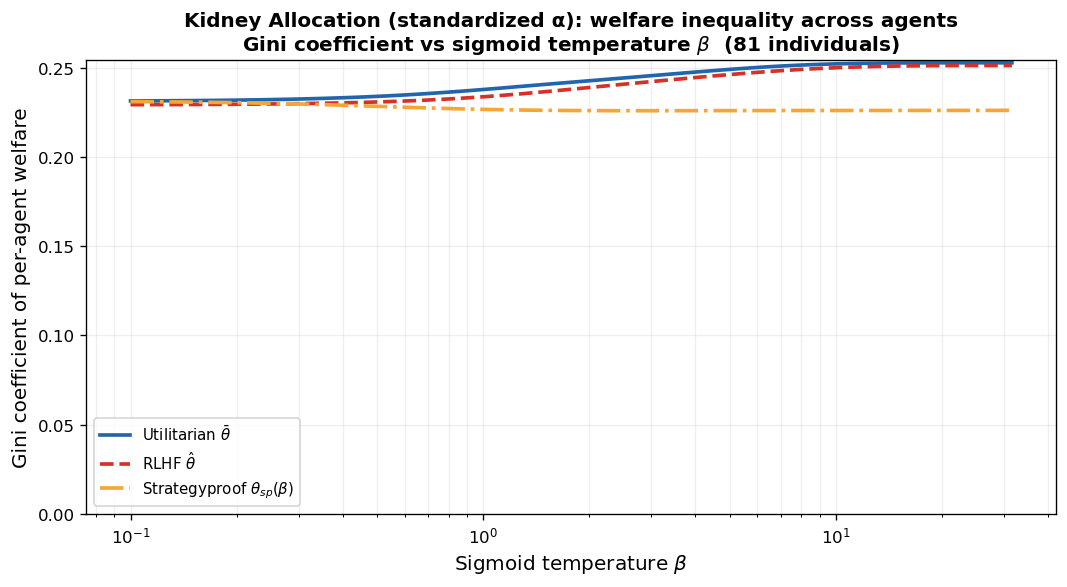

Utilitarian     β=0.1: 0.231   β=1: 0.238   β=32: 0.253
RLHF            β=0.1: 0.229   β=1: 0.234   β=32: 0.251
SP              β=0.1: 0.231   β=1: 0.227   β=32: 0.226


In [38]:
# ── Gini coefficient vs β — Kidney (standardized alpha) ──────────────────

from scipy.special import expit
from scipy.optimize import minimize

theta_arr_s  = theta_std_df[FEAT_COLS].values.astype(float)
N_agents     = len(theta_arr_s)
w_uniform    = np.ones(N_agents) / N_agents
theta_bar_s  = w_uniform @ theta_arr_s
theta_rlhf_s = theta_hat_std

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

def gini(values):
    v = np.array(values, dtype=float)
    v = v - v.min()
    if v.sum() < 1e-12:
        return 0.0
    v = np.sort(v)
    N = len(v)
    return float((2 * (np.arange(1, N + 1) * v).sum()) / (N * v.sum()) - (N + 1) / N)

betas = np.logspace(-1, 1.5, 100)

gini_util, gini_rlhf, gini_sp = [], [], []
theta_sp_prev = theta_bar_s.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr_s, b, alpha_std).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_std, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    W_util = per_agent_welfare(theta_bar_s,  b, theta_arr_s, alpha_std)
    W_rlhf = per_agent_welfare(theta_rlhf_s, b, theta_arr_s, alpha_std)
    W_sp   = per_agent_welfare(theta_sp,     b, theta_arr_s, alpha_std)

    gini_util.append(gini(W_util))
    gini_rlhf.append(gini(W_rlhf))
    gini_sp.append(  gini(W_sp))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, gini_util, color='#2166ac', lw=2.2, ls='-',
        label=r'Utilitarian $\bar\theta$')
ax.plot(betas, gini_rlhf, color='#d73027', lw=2.2, ls='--',
        label=r'RLHF $\hat\theta$')
ax.plot(betas, gini_sp,   color='#f4a736', lw=2.2, ls='-.',
        label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel('Gini coefficient of per-agent welfare', fontsize=12)
ax.set_title('Kidney Allocation (standardized α): welfare inequality across agents\n'
             r'Gini coefficient vs sigmoid temperature $\beta$  (81 individuals)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

for lbl, arr in [('Utilitarian', gini_util), ('RLHF', gini_rlhf), ('SP', gini_sp)]:
    print(f'{lbl:14s}  β=0.1: {arr[0]:.3f}   β=1: {arr[np.argmin(np.abs(betas-1))]:.3f}'
          f'   β=32: {arr[-1]:.3f}')


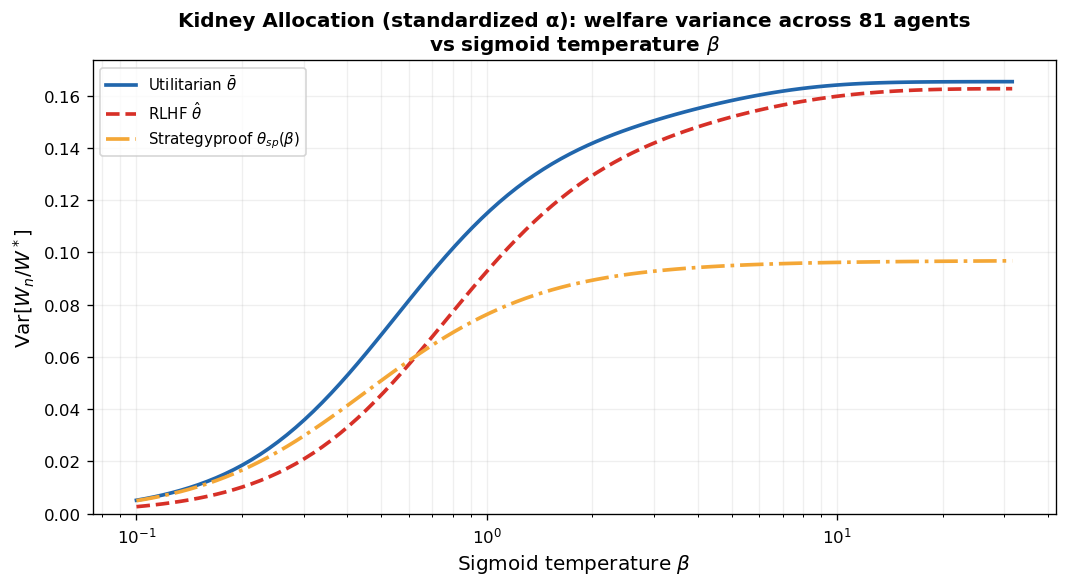

Utilitarian     β=0.1: 0.0052   β=1: 0.1161   β=32: 0.1653
RLHF            β=0.1: 0.0027   β=1: 0.0942   β=32: 0.1626
SP              β=0.1: 0.0050   β=1: 0.0769   β=32: 0.0968


In [40]:
# ── Welfare variance across agents vs β — Kidney Allocation (standardized α) ────────────────
#
# For each mechanism and each β:
#   Var[W_n(θ_c; β)] = (1/N) Σ_n (W_n − W̄)²
# Normalized by W*² to give a dimensionless relative variance.

from scipy.special import expit
from scipy.optimize import minimize

theta_arr  = theta_std_df[FEAT_COLS].values.astype(float)
w_uniform  = np.ones(len(theta_arr)) / len(theta_arr)
theta_bar  = w_uniform @ theta_arr
theta_rlhf = theta_hat_std

def phi_all(theta_agents, beta, alpha):
    logits = alpha @ theta_agents.T
    factor = (expit(beta * logits) - 0.5)
    return factor.T @ alpha / len(alpha)

def phi_inv(target, beta, alpha, theta_init=None):
    if theta_init is None:
        theta_init = np.zeros(alpha.shape[1])
    def loss_and_grad(theta):
        s        = expit(beta * (alpha @ theta))
        phi_t    = ((s - 0.5)[:, None] * alpha).mean(axis=0)
        residual = phi_t - target
        v        = s * (1 - s)
        J        = (alpha * (beta * v)[:, None]).T @ alpha / len(alpha)
        return 0.5 * np.dot(residual, residual), J @ residual
    res = minimize(loss_and_grad, theta_init, jac=True, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-14, 'gtol': 1e-8})
    return res.x

def per_agent_welfare(theta_deploy, beta, theta_agents, alpha):
    factor = (expit(beta * (alpha @ theta_deploy)) - 0.5)
    return (alpha @ theta_agents.T * factor[:, None]).mean(axis=0)

psi_star  = (np.sign(alpha_std @ theta_bar)[:, None] * alpha_std).mean(axis=0)
W_star    = 0.5 * float(theta_bar @ psi_star)
betas     = np.logspace(-1, 1.5, 100)

var_util, var_rlhf, var_sp = [], [], []
theta_sp_prev = theta_bar.copy()

for b in betas:
    phi_avg       = phi_all(theta_arr, b, alpha_std).mean(axis=0)
    theta_sp      = phi_inv(phi_avg, b, alpha_std, theta_init=theta_sp_prev)
    theta_sp_prev = theta_sp.copy()

    W_util = per_agent_welfare(theta_bar,  b, theta_arr, alpha_std)
    W_rlhf = per_agent_welfare(theta_rlhf, b, theta_arr, alpha_std)
    W_sp   = per_agent_welfare(theta_sp,   b, theta_arr, alpha_std)

    W_star_sq = W_star ** 2
    var_util.append(W_util.var() / W_star_sq)
    var_rlhf.append(W_rlhf.var() / W_star_sq)
    var_sp.append(  W_sp.var()   / W_star_sq)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(betas, var_util, color='#2166ac', lw=2.2, ls='-',
        label=r'Utilitarian $\bar\theta$')
ax.plot(betas, var_rlhf, color='#d73027', lw=2.2, ls='--',
        label=r'RLHF $\hat\theta$')
ax.plot(betas, var_sp,   color='#f4a736', lw=2.2, ls='-.',
        label=r'Strategyproof $\theta_{sp}(\beta)$')
ax.set_xscale('log')
ax.set_ylim(bottom=0)
ax.set_xlabel(r'Sigmoid temperature $\beta$', fontsize=12)
ax.set_ylabel(r'Var$[W_n / W^*]$', fontsize=12)
ax.set_title('Kidney Allocation (standardized α): welfare variance across 81 agents\n'
             r'vs sigmoid temperature $\beta$', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.2)
plt.tight_layout()
plt.show()

for lbl, arr in [('Utilitarian', var_util), ('RLHF', var_rlhf), ('SP', var_sp)]:
    print(f'{lbl:14s}  β=0.1: {arr[0]:.4f}   β=1: {arr[np.argmin(np.abs(betas-1))]:.4f}'
          f'   β=32: {arr[-1]:.4f}')


In [39]:
# # ── Visualize Ψ for kidney data ───────────────────────────────────────────
# def psi_batch(thetas, A):
#     """thetas (M, k), A (Q, k) -> impact vectors (M, k)."""
#     w = (sigmoid(thetas @ A.T) - 0.5)      # (M, Q)
#     return (w[:, :, None] * A[None]).mean(axis=1)  # (M, k)

# def psi_single(theta, A):
#     w = (sigmoid(A @ theta) - 0.5)
#     return (A * w[:, None]).mean(axis=0)

# # Sweep θ over many directions + radii in R^5
# rng_vis   = np.random.default_rng(0)
# n_dirs    = 3000
# raw_dirs  = rng_vis.standard_normal((n_dirs, len(FEAT_COLS)))
# unit_dirs = raw_dirs / np.linalg.norm(raw_dirs, axis=1, keepdims=True)
# radii = np.concatenate([np.linspace(0, 0.5, 10),
#                          np.linspace(0.5, 5, 30),
#                          np.geomspace(5, 200, 20)])
# all_theta = np.vstack([r * unit_dirs for r in radii])

# # Standardize alpha (prevents scale dominance in PCA)
# feat_std      = alpha_all.std(axis=0)
# feat_std      = np.where(feat_std < 1e-10, 1.0, feat_std)
# all_theta_std = all_theta * feat_std[None, :]   # compensate in theta space

# # Named vectors to annotate
# named = {
#     'theta_hat (RLHF)': theta_hat,
#     **{f'cluster_{g}': theta_groups[g] for g in range(best_k)},
#     'theta_bar (wt)': theta_clust_wt,
# }
# markers = ['*', 'D', 's', '^', 'o', 'P', 'X', 'v', '<', '>', 'h', 'H']

# fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# for ax, (q_label, A_dep) in zip(axes, [
#     ('Empirical q_dep', alpha_all),
#     ('Uniform q_dep (random)', make_uniform_qdep_kidney()),
# ]):
#     A_dep_s = A_dep / feat_std[None, :]
#     all_psi = psi_batch(all_theta_std, A_dep_s)   # (M, 5)
#     pca     = PCA(n_components=2).fit(all_psi)
#     psi_2d  = pca.transform(all_psi)

#     hb = ax.hexbin(psi_2d[:, 0], psi_2d[:, 1], gridsize=60, cmap='YlOrRd',
#                    mincnt=1, linewidths=0)
#     plt.colorbar(hb, ax=ax, label='# theta values')

#     for (lbl, th), mk in zip(named.items(), markers):
#         th_s = th / feat_std
#         p = pca.transform(psi_single(th_s, A_dep_s).reshape(1, -1))
#         ax.scatter(p[0, 0], p[0, 1], s=160, marker=mk, zorder=10,
#                    label=lbl, edgecolors='black', linewidths=0.7)

#     ax.scatter([0], [0], c='black', s=60, marker='x', zorder=9)
#     ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
#     ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
#     ax.set_title(q_label, fontweight='bold')
#     ax.legend(fontsize=8, loc='upper left')

#     print(f'\n── {q_label} PCA loadings ──')
#     loadings = pd.DataFrame(pca.components_.T, index=FEAT_COLS, columns=['PC1', 'PC2'])
#     for ax_name in ['PC1', 'PC2']:
#         top = loadings[ax_name].abs().nlargest(5).index.tolist()
#         print(f'  {ax_name}: ' + ', '.join(
#             f'{c}({loadings.loc[c, ax_name]:+.2f})' for c in top))
#     print(f'  Variance: PC1={pca.explained_variance_ratio_[0]:.1%}  '
#           f'PC2={pca.explained_variance_ratio_[1]:.1%}  '
#           f'total={pca.explained_variance_ratio_.sum():.1%}')

# plt.suptitle('Impact set Ψ — Kidney allocation (k=5 features, PCA projection)',
#              fontweight='bold', fontsize=13)
# plt.tight_layout()
# plt.show()